# ch288 — Entropy

*(Directly extends ch287 — Information Theory; connects to decision trees and compression)*

## 1. Shannon Entropy

Entropy is the **expected surprisal** of a distribution — the average information content per outcome:

$$H(X) = -\sum_{x} P(x) \log P(x) = E[-\log P(X)]$$

For continuous distributions (differential entropy):
$$h(X) = -\int p(x) \log p(x) \, dx$$

Entropy is maximized by the uniform distribution and minimized (= 0) by a point mass.

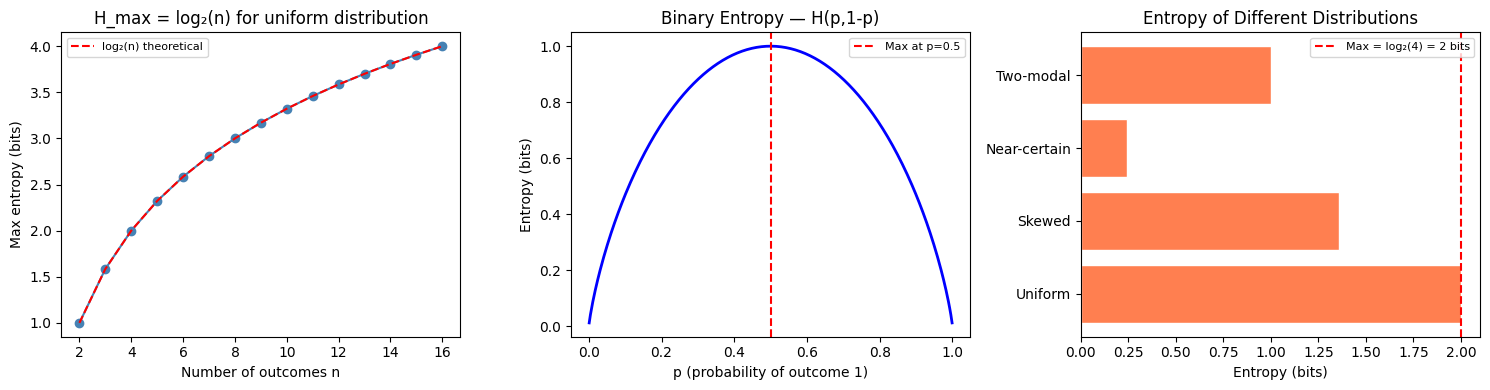

Uniform        : H = 2.0000 bits
Skewed         : H = 1.3568 bits
Near-certain   : H = 0.2419 bits
Two-modal      : H = 1.0000 bits


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def entropy(probs: np.ndarray, base: str = 'nats') -> float:
    """
    Shannon entropy of a discrete distribution.
    probs must sum to 1; zero entries contribute 0 (lim p→0 of p log p = 0).
    """
    probs = np.asarray(probs, dtype=float)
    probs = probs[probs > 0]  # 0 * log(0) = 0 by convention
    if base == 'bits':
        return -np.sum(probs * np.log2(probs))
    return -np.sum(probs * np.log(probs))

# Maximum entropy: uniform distribution
n_outcomes = np.arange(2, 17)
max_entropies = [entropy(np.full(n, 1/n), 'bits') for n in n_outcomes]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Max entropy vs n
axes[0].plot(n_outcomes, max_entropies, 'o-', color='steelblue')
axes[0].plot(n_outcomes, np.log2(n_outcomes), 'r--', label='log₂(n) theoretical')
axes[0].set_xlabel('Number of outcomes n')
axes[0].set_ylabel('Max entropy (bits)')
axes[0].set_title('H_max = log₂(n) for uniform distribution')
axes[0].legend(fontsize=8)

# 2. Entropy vs concentration
p = np.linspace(0.001, 0.999, 300)
h_binary = entropy(np.column_stack([p, 1-p]).T[0].reshape(-1,2)[0:1].flatten())
h_vals = np.array([entropy([pi, 1-pi], 'bits') for pi in p])
axes[1].plot(p, h_vals, 'b-', lw=2)
axes[1].set_xlabel('p (probability of outcome 1)')
axes[1].set_ylabel('Entropy (bits)')
axes[1].set_title('Binary Entropy — H(p,1-p)')
axes[1].axvline(0.5, color='red', ls='--', label='Max at p=0.5')
axes[1].legend(fontsize=8)

# 3. Compare distributions
distributions = {
    'Uniform':      [0.25, 0.25, 0.25, 0.25],
    'Skewed':       [0.7,  0.1,  0.1,  0.1],
    'Near-certain': [0.97, 0.01, 0.01, 0.01],
    'Two-modal':    [0.5,  0.0,  0.0,  0.5],
}
entropies = {k: entropy(v, 'bits') for k, v in distributions.items()}
axes[2].barh(list(entropies.keys()), list(entropies.values()), color='coral', edgecolor='white')
axes[2].axvline(np.log2(4), color='red', ls='--', label='Max = log₂(4) = 2 bits')
axes[2].set_xlabel('Entropy (bits)')
axes[2].set_title('Entropy of Different Distributions')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

for name, dist in distributions.items():
    print(f"{name:<15}: H = {entropy(dist, 'bits'):.4f} bits")

## 2. Conditional Entropy and Information Gain

In [2]:
def conditional_entropy(
    joint: np.ndarray  # shape (|X|, |Y|), joint probability table
) -> float:
    """H(Y|X) = sum_x P(X=x) H(Y|X=x). In nats."""
    px = joint.sum(axis=1)         # marginal P(X)
    h_y_given_x = 0.0
    for i, px_i in enumerate(px):
        if px_i > 0:
            p_y_given_x = joint[i] / px_i  # P(Y|X=x_i)
            h_y_given_x += px_i * entropy(p_y_given_x)
    return h_y_given_x

def information_gain(
    y: np.ndarray,
    x: np.ndarray,
) -> float:
    """
    Information gain of Y given X: IG(Y;X) = H(Y) - H(Y|X).
    y and x are 1D integer arrays.
    """
    y_vals = np.unique(y)
    x_vals = np.unique(x)
    p_y    = np.array([np.mean(y == yv) for yv in y_vals])
    h_y    = entropy(p_y)

    h_y_x  = 0.0
    for xv in x_vals:
        mask  = x == xv
        p_xv  = mask.mean()
        p_y_given_x = np.array([np.mean(y[mask] == yv) for yv in y_vals])
        h_y_x += p_xv * entropy(p_y_given_x)

    return h_y - h_y_x


# Example: decision tree feature selection
rng = np.random.default_rng(0)
n   = 500

# Target: y depends on f1 and f2, not f3
f1 = rng.choice([0, 1, 2], n)       # 3 categories
f2 = rng.choice([0, 1], n)           # binary
f3 = rng.choice([0, 1, 2, 3], n)    # 4 categories (noise)
y  = ((f1 > 0).astype(int) + f2) % 2

ig_f1 = information_gain(y, f1)
ig_f2 = information_gain(y, f2)
ig_f3 = information_gain(y, f3)

print("Information Gain (bits equivalent via /log(2)):")
print(f"  H(Y):          {entropy(np.array([y.mean(), 1-y.mean()])):.4f} nats")
print(f"  IG(Y; F1):     {ig_f1:.4f} nats  {'← informative' if ig_f1 > 0.05 else ''}")
print(f"  IG(Y; F2):     {ig_f2:.4f} nats  {'← informative' if ig_f2 > 0.05 else ''}")
print(f"  IG(Y; F3):     {ig_f3:.4f} nats  {'← noise' if ig_f3 < 0.02 else ''}")
print()
print("Decision trees split on the feature with highest information gain.")
print("This is why IG is used for feature selection (ch291).")

Information Gain (bits equivalent via /log(2)):
  H(Y):          0.6929 nats
  IG(Y; F1):     0.0010 nats  
  IG(Y; F2):     0.0738 nats  ← informative
  IG(Y; F3):     0.0014 nats  ← noise

Decision trees split on the feature with highest information gain.
This is why IG is used for feature selection (ch291).


## 3. Entropy of Continuous Distributions

In [3]:
# Differential entropy: h(X) = -integral p(x) log p(x) dx
# For Gaussian: h = 0.5 * log(2πeσ²)

def gaussian_differential_entropy(sigma: float) -> float:
    """Exact formula: h(N(mu, sigma²)) = 0.5 * ln(2πe * sigma²) nats."""
    return 0.5 * np.log(2 * np.pi * np.e * sigma**2)

sigmas = [0.5, 1.0, 2.0, 5.0, 10.0]
print("Gaussian differential entropy:")
for s in sigmas:
    print(f"  σ={s:.1f}: h = {gaussian_differential_entropy(s):.4f} nats")

print()
print("Key insight: wider distributions have higher entropy.")
print("Among all distributions with variance σ², the Gaussian maximizes entropy.")
print("This is why Gaussian noise is the 'hardest' noise to remove.")

Gaussian differential entropy:
  σ=0.5: h = 0.7258 nats
  σ=1.0: h = 1.4189 nats
  σ=2.0: h = 2.1121 nats
  σ=5.0: h = 3.0284 nats
  σ=10.0: h = 3.7215 nats

Key insight: wider distributions have higher entropy.
Among all distributions with variance σ², the Gaussian maximizes entropy.
This is why Gaussian noise is the 'hardest' noise to remove.


## 4. What Comes Next

The cross-entropy loss $H(P, Q)$ decomposes as $H(P) + D_{KL}(P\|Q)$. Since $H(P)$ (the true label entropy) is fixed during training, minimizing cross-entropy is equivalent to minimizing KL divergence from predictions to true labels. **ch289 — KL Divergence** develops this quantity, which is central to variational inference, VAEs, and distribution matching in generative models.